---
date: "2026-07-20"
date-modified: last-modified
format:
  html:
    toc: true
---


# Law of Large Numbers and Central Limit Theorem

The fundamental limit theorems of probability theory—the **Law of Large Numbers (LLN)** and the **Central Limit Theorem (CLT)**—describe the asymptotic behavior of sample averages as the sample size grows to infinity. While the Law of Large Numbers establishes that sample averages converge to the true population expectation, the Central Limit Theorem reveals the exact universal fluctuations around that expectation.

## 1\. Introduction and Sample Mean Setup

Throughout this note, we consider a sequence of [random variables](random-variables.ipynb) drawn independently from a common probability distribution.

::: {#def-sample-mean}
## Sample Mean
Let $X_1, X_2, X_3, \dots$ be a sequence of independent and identically distributed ([i.i.d.](independence-of-rvs.ipynb)) [random variables](random-variables.ipynb) with finite [expected value](expectation.ipynb) $E(X_i) = \mu$ and finite [variance](variance.ipynb) $\text{Var}(X_i) = \sigma^2$. For any sample size $n \in \mathbb{N}$, the **sample mean** $\bar{X}_n$ is defined as:
$$ \bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i $$
:::

By linearity of expectation and the independence of the random variables, the first and second moments of the sample mean are given by:

$$
\begin{aligned}
E(\bar{X}_n) &= E\left( \frac{1}{n} \sum_{i=1}^n X_i \right) = \frac{1}{n} \sum_{i=1}^n E(X_i) = \frac{1}{n} (n\mu) = \mu \\
\text{Var}(\bar{X}_n) &= \text{Var}\left( \frac{1}{n} \sum_{i=1}^n X_i \right) = \frac{1}{n^2} \sum_{i=1}^n \text{Var}(X_i) = \frac{1}{n^2} (n\sigma^2) = \frac{\sigma^2}{n}
\end{aligned}
$$

Notice that while the expectation of $\bar{X}_n$ remains constantly fixed at the true population mean $\mu$, the variance $\text{Var}(\bar{X}_n) = \frac{\sigma^2}{n}$ shrinks to zero inversely with the sample size $n$. This shrinking variance is the foundational driving force behind all concentration and convergence theorems.


## 2\. Weak Law of Large Numbers (WLLN)

The **Weak Law of Large Numbers (WLLN)** states that as the sample size increases, the sample mean $\bar{X}_n$ concentrates tightly around the true population expectation $\mu$, such that the probability of any macroscopic deviation approaches zero. This mode of convergence is formally known as [convergence in probability]().

::: {#thm-weak-lln}
## Weak Law of Large Numbers
Let $X_1, X_2, \dots, X_n$ be [i.i.d.](independence-of-rvs.ipynb) [random variables](random-variables.ipynb) with finite mean $E(X_i) = \mu$ and finite variance $\text{Var}(X_i) = \sigma^2$. For any given error threshold $\epsilon > 0$ (or $c > 0$), the probability that the sample mean deviates from the true mean by more than $\epsilon$ converges to zero:
$$ \lim_{n \to \infty} \mathbb{P}\left( |\bar{X}_n - \mu| > \epsilon \right) = 0 $$
Equivalently, $\bar{X}_n$ converges in probability to $\mu$, denoted $\bar{X}_n \xrightarrow{P} \mu$.
:::

::: {.callout-tip collapse="true"}
## Proof of the Weak Law of Large Numbers
We apply [Chebyshev's Inequality](chebyshevs-inequality.ipynb) directly to the sample mean $\bar{X}_n$. 

Recall that for any random variable $Y$ with finite mean $\mu_Y$ and finite variance $\sigma_Y^2$, [Chebyshev's Inequality](chebyshevs-inequality.ipynb) guarantees that for any $c > 0$:
$$ \mathbb{P}\left( |Y - \mu_Y| \ge c \right) \le \frac{\text{Var}(Y)}{c^2} $$

Setting $Y = \bar{X}_n$, we substitute its known mean $E(\bar{X}_n) = \mu$ and variance $\text{Var}(\bar{X}_n) = \frac{\sigma^2}{n}$ into the bound for any arbitrary deviation threshold $c > 0$:
$$
\begin{aligned}
\mathbb{P}\left( |\bar{X}_n - \mu| \ge c \right) &\le \frac{\text{Var}(\bar{X}_n)}{c^2} \\
&= \frac{\frac{1}{n} \sigma^2}{c^2} \\
&= \frac{\sigma^2}{n c^2}
\end{aligned}
$$

Taking the limit of both sides as the sample size grows to infinity ($n \to \infty$):
$$ \lim_{n \to \infty} \mathbb{P}\left( |\bar{X}_n - \mu| \ge c \right) \le \lim_{n \to \infty} \frac{\sigma^2}{n c^2} = 0 $$

Since probabilities are non-negative ($\mathbb{P} \ge 0$), the squeeze theorem forces:
$$ \lim_{n \to \infty} \mathbb{P}\left( |\bar{X}_n - \mu| \ge c \right) = 0 $$
This confirms that for any positive deviation threshold, the probability of exceeding that threshold vanishes asymptotically. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Concentration of Measure
The Weak Law of Large Numbers demonstrates that random errors tend to cancel out when averaged across many independent trials. Because individual fluctuations occur above and below the mean, summing $n$ independent variables causes their variances to add linearly ($n\sigma^2$), whereas dividing by $n$ scales the average's variance by $\frac{1}{n^2}$. The net effect is a variance reduction proportional to $\frac{1}{n}$, squeezing the distribution of $\bar{X}_n$ into an infinitely narrow spike centered exactly at $\mu$.
:::


## 3\. The Rabbit-Turtle Method and Rate of Convergence

While the Law of Large Numbers establishes that $\bar{X}_n - \mu \to 0$, a natural and fundamental question arises: **What is the exact distribution of $\bar{X}_n - \mu$ during this transition, and how fast does it converge to zero?**

To answer this, we can use a scaling technique known informally as the **"Rabbit-Turtle Method"** (rate scaling analysis). We multiply the vanishing difference $\bar{X}_n - \mu$ by an "exploding" polynomial rate term $n^p$ ($p > 0$) to see which exponent balances the decay exactly:

$$ Z_n(p) = n^p (\bar{X}_n - \mu) $$

Let us inspect how the variance of this scaled process behaves as $n \to \infty$ across different choices of the exponent $p$:

$$
\begin{aligned}
\text{Var}\left( Z_n(p) \right) &= \text{Var}\left( n^p (\bar{X}_n - \mu) \right) \\
&= n^{2p} \text{Var}(\bar{X}_n) \\
&= n^{2p} \left( \frac{\sigma^2}{n} \right) \\
&= \sigma^2 n^{2p - 1}
\end{aligned}
$$

We observe three distinct asymptotic regimes depending on the exponent $p$:

1. **The Sub-Critical Regime ($p < \frac{1}{2}$):** If $p < \frac{1}{2}$, the exponent $2p - 1$ is negative. Therefore, $\lim_{n \to \infty} \text{Var}(Z_n(p)) = 0$. The decay of $\bar{X}_n - \mu$ to zero is stronger than the growth of $n^p$, so the scaled product still collapses to zero: $n^p(\bar{X}_n - \mu) \xrightarrow{P} 0$.
2. **The Super-Critical Regime ($p > \frac{1}{2}$):** If $p > \frac{1}{2}$, the exponent $2p - 1$ is positive. Therefore, $\lim_{n \to \infty} \text{Var}(Z_n(p)) = \infty$. The exploding term $n^p$ grows too fast, causing the scaled fluctuations to blow up to infinity.
3. **The Critical Balance ($p = \frac{1}{2}$):** When $p = \frac{1}{2}$, the exponent becomes $2\left(\frac{1}{2}\right) - 1 = 0$. The variance of the scaled term is perfectly preserved for all $n$:
   $$ \text{Var}\left( n^{1/2} (\bar{X}_n - \mu) \right) = \sigma^2 n^0 = \sigma^2 $$

::: {.callout-note}
## Intuition: Why $p = 1/2$ Unlocks the Central Limit Theorem
The rate scaling analysis proves that the difference $\bar{X}_n - \mu$ approaches zero at a rate precisely proportional to $\frac{1}{\sqrt{n}}$. By multiplying by $n^{1/2} = \sqrt{n}$, we arrest the collapse to zero without allowing the variance to explode. This exact normalization stabilizes the random variable, revealing a universal, non-degenerate limiting distribution: the Normal distribution $\mathcal{N}(0, \sigma^2)$.
:::


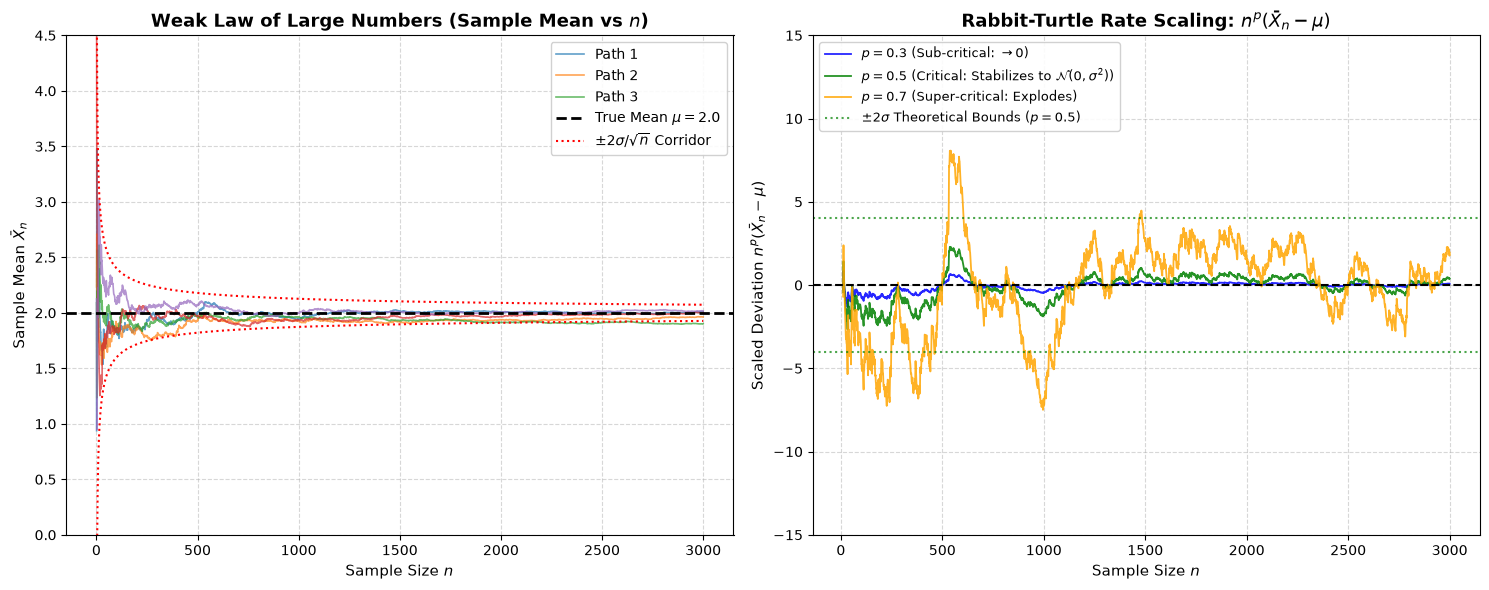

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulation parameters: Exponential distribution with mean mu=2.0 and SD sigma=2.0
mu = 2.0
sigma = 2.0
max_n = 3000
n_values = np.arange(1, max_n + 1)

# Generate 5 independent sample paths of X_i ~ Exp(1/mu)
num_paths = 5
sample_paths = np.random.exponential(scale=mu, size=(num_paths, max_n))
sample_means = np.cumsum(sample_paths, axis=1) / n_values

# Setup figure with two subplots: WLLN trajectories and Rabbit-Turtle rate scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Convergence of Sample Means (WLLN)
for i in range(num_paths):
    ax1.plot(n_values, sample_means[i], alpha=0.7, lw=1.2, label=f"Path {i+1}" if i < 3 else "")

# Theoretical confidence corridor (+/- 2 * sigma / sqrt(n))
ax1.axhline(mu, color='black', linestyle='--', lw=2, label=r'True Mean $\mu = 2.0$')
ax1.plot(n_values, mu + 2 * sigma / np.sqrt(n_values), color='red', linestyle=':', lw=1.5, label=r'$\pm 2\sigma / \sqrt{n}$ Corridor')
ax1.plot(n_values, mu - 2 * sigma / np.sqrt(n_values), color='red', linestyle=':', lw=1.5)

ax1.set_title(r"Weak Law of Large Numbers (Sample Mean vs $n$)", fontsize=13, fontweight='bold')
ax1.set_xlabel(r"Sample Size $n$", fontsize=11)
ax1.set_ylabel(r"Sample Mean $\bar{X}_n$", fontsize=11)
ax1.set_ylim(0, 4.5)
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Rabbit-Turtle Rate Scaling Analysis n^p * (X_bar - mu)
single_path_mean = sample_means[0]
diff = single_path_mean - mu

p_values = [0.3, 0.5, 0.7]
colors = ['blue', 'green', 'orange']
labels = [r'$p=0.3$ (Sub-critical: $\rightarrow 0$)', r'$p=0.5$ (Critical: Stabilizes to $\mathcal{N}(0,\sigma^2)$)', r'$p=0.7$ (Super-critical: Explodes)']

for p, col, lab in zip(p_values, colors, labels):
    scaled_process = (n_values ** p) * diff
    ax2.plot(n_values[10:], scaled_process[10:], color=col, lw=1.3, alpha=0.85, label=lab)

ax2.axhline(0, color='black', linestyle='--', lw=1.5)
ax2.axhline(2 * sigma, color='green', linestyle=':', lw=1.5, alpha=0.7, label=r'$\pm 2\sigma$ Theoretical Bounds ($p=0.5$)')
ax2.axhline(-2 * sigma, color='green', linestyle=':', lw=1.5, alpha=0.7)

ax2.set_title(r"Rabbit-Turtle Rate Scaling: $n^p (\bar{X}_n - \mu)$", fontsize=13, fontweight='bold')
ax2.set_xlabel(r"Sample Size $n$", fontsize=11)
ax2.set_ylabel(r"Scaled Deviation $n^p (\bar{X}_n - \mu)$", fontsize=11)
ax2.set_ylim(-15, 15)
ax2.legend(loc='upper left', framealpha=0.9, fontsize=9.5)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 4\. Strong Law of Large Numbers (SLLN)

While the Weak Law of Large Numbers guarantees convergence in probability ($\bar{X}_n \xrightarrow{P} \mu$), the **Strong Law of Large Numbers (SLLN)** provides a significantly stronger guarantee: sample averages converge to the population mean **with probability $1$** (also known as [convergence almost surely](), denoted $\bar{X}_n \xrightarrow{a.s.} \mu$).

::: {#thm-strong-lln}
## Strong Law of Large Numbers (Kolmogorov's Strong Law)
Let $X_1, X_2, \dots$ be a sequence of [i.i.d.](independence-of-rvs.ipynb) [random variables](random-variables.ipynb). Then the sample mean converges almost surely to $\mu$ if and only if the expectation $E(|X_i|)$ is finite, in which case:
$$ \mathbb{P}\left( \lim_{n \to \infty} \bar{X}_n = \mu \right) = 1 $$
:::

::: {.callout-warning}
## Distinction: Weak vs. Strong Convergence
It is vital to understand the conceptual difference between the Weak and Strong Laws:

1. **Weak Law ($\bar{X}_n \xrightarrow{P} \mu$):** States that at any single fixed, large time step $n$, the probability that the trajectory is far from $\mu$ is negligible. However, it does not rule out the possibility that a sample path might occasionally jump away from $\mu$ at arbitrarily large times (as long as such excursions become infinitely infrequent in probability).
2. **Strong Law ($\bar{X}_n \xrightarrow{a.s.} \mu$):** States that if you observe the entire infinite sample path of averages $\bar{X}_1, \bar{X}_2, \bar{X}_3, \dots$, the probability that this specific path eventually stays within any $\epsilon$-neighborhood of $\mu$ forever is exactly $1$. Almost all trajectories converge to $\mu$ without any late deviations.
:::

### 4.1\. Example: Sample Proportions in Bernoulli Trials

Consider a sequence of independent coin flips or binary experiments where each trial yields a success ($1$) with probability $p$ and failure ($0$) with probability $1-p$. Let $X_i \sim \text{Bern}(p)$ ([Bernoulli distribution](bernoulli-and-binomial-distributions.ipynb)).

The true mean expectation is $E(X_i) = 1 \cdot p + 0 \cdot (1-p) = p$. The sample mean $\bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i$ represents the empirical proportion of successes $\hat{p}_n$ after $n$ trials.

By direct application of the Strong Law of Large Numbers:
$$ \mathbb{P}\left( \lim_{n \to \infty} \frac{X_1 + X_2 + \dots + X_n}{n} = p \right) = 1 $$
This guarantees that empirical relative frequencies in repeated independent trials almost surely converge to the underlying probability $p$, establishing the rigorous mathematical foundation for the frequentist interpretation of probability.


## 5\. Central Limit Theorem (CLT)

Building upon the "Rabbit-Turtle" rate scaling discovery ($p = \frac{1}{2}$), the **Central Limit Theorem (CLT)** proves that once we standardize the sample mean by its true standard deviation $\frac{\sigma}{\sqrt{n}}$, the resulting distribution converges universally to the standard [Normal distribution](normal-distribution.ipynb) $\mathcal{N}(0, 1)$, regardless of the original shape of the parent distribution.

::: {#thm-clt}
## Central Limit Theorem (Lindeberg-Lévy CLT)
Let $X_1, X_2, \dots, X_n$ be [i.i.d.](independence-of-rvs.ipynb) [random variables](random-variables.ipynb) with mean $E(X_i) = \mu$ and finite variance $\text{Var}(X_i) = \sigma^2 > 0$. As $n \to \infty$, the standardized sample mean converges in distribution to the standard [Normal distribution](normal-distribution.ipynb):
$$ n^{1/2} \left( \frac{\bar{X}_n - \mu}{\sigma} \right) \xrightarrow{d} \mathcal{N}(0, 1) $$
Equivalently, writing the standardization in terms of the partial sum $S_n = \sum_{j=1}^n X_j$:
$$ \frac{\sum_{j=1}^n X_j - n\mu}{\sqrt{n} \sigma} \xrightarrow{d} \mathcal{N}(0, 1) \quad \text{in distribution.} $$
:::

This means that for any real numbers $a < b$:
$$ \lim_{n \to \infty} \mathbb{P}\left( a \le \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \le b \right) = \int_a^b \frac{1}{\sqrt{2\pi}} e^{-z^2 / 2} \, dz = \Phi(b) - \Phi(a) $$
where $\Phi(z)$ denotes the cumulative distribution function ([CDF](cumulative-distribution-functions.ipynb)) of the standard normal distribution $\mathcal{N}(0, 1)$.


## 6\. Proof of the Central Limit Theorem via Moment Generating Functions

We now provide a rigorous, step-by-step proof of the Central Limit Theorem using [moment generating functions (MGFs)](moment-generating-functions.ipynb) and [L'Hôpital's Rule]().

::: {.callout-tip collapse="true"}
## Proof of the Central Limit Theorem
Assume that the [moment generating function](moment-generating-functions.ipynb) $M(t) = E(e^{tX_i})$ of $X_i$ exists and is finite in an open neighborhood around $t = 0$.

**Step 1: Standardize without loss of generality (WLOG)**
Let $\mu = 0$ and $\sigma = 1$. If the original variables have non-zero mean or non-unit variance, we can define standardized variables $Z_i = \frac{X_i - \mu}{\sigma}$, which automatically satisfy $E(Z_i) = 0$ and $\text{Var}(Z_i) = 1$. Under this WLOG assumption, we define the partial sum $S_n = \sum_{j=1}^n X_j$, and our goal is to show that the MGF of $\frac{S_n}{\sqrt{n}}$ converges to the MGF of $\mathcal{N}(0, 1)$, which is $e^{t^2 / 2}$.

**Step 2: Express the MGF of the scaled sum**
By definition of the MGF and using the mutual independence of $X_1, X_2, \dots, X_n$:
$$
\begin{aligned}
E\left( e^{t \frac{S_n}{\sqrt{n}}} \right) &= E\left( e^{t \frac{X_1 + X_2 + \dots + X_n}{\sqrt{n}}} \right) \\
&= E\left( e^{\frac{t}{\sqrt{n}} X_1 + \frac{t}{\sqrt{n}} X_2 + \dots + \frac{t}{\sqrt{n}} X_n} \right) \\
&= E\left( e^{\frac{t}{\sqrt{n}} X_1} e^{\frac{t}{\sqrt{n}} X_2} \dots e^{\frac{t}{\sqrt{n}} X_n} \right) \\
&= E\left( e^{\frac{t}{\sqrt{n}} X_1} \right) \times E\left( e^{\frac{t}{\sqrt{n}} X_2} \right) \times \dots \times E\left( e^{\frac{t}{\sqrt{n}} X_n} \right) \\
&= \left( M\left( \frac{t}{\sqrt{n}} \right) \right)^n
\end{aligned}
$$

**Step 3: Analyze the logarithm of the MGF**
To evaluate the limit $\lim_{n \to \infty} \left( M\left( \frac{t}{\sqrt{n}} \right) \right)^n$, we take the natural logarithm and evaluate its limit:
$$
\begin{aligned}
L &= \lim_{n \to \infty} \ln \left[ \left( M\left( \frac{t}{\sqrt{n}} \right) \right)^n \right] \\
&= \lim_{n \to \infty} n \ln M\left( \frac{t}{\sqrt{n}} \right) \\
&= \lim_{n \to \infty} \frac{\ln M\left( \frac{t}{\sqrt{n}} \right)}{\frac{1}{n}}
\end{aligned}
$$

Let $y = \frac{1}{\sqrt{n}}$, treating $y$ as a continuous real variable that approaches $0$ as $n \to \infty$. Since $\frac{1}{n} = y^2$, our limit transforms into:
$$ L = \lim_{y \to 0} \frac{\ln M(yt)}{y^2} $$

**Step 4: First application of L'Hôpital's Rule**
As $y \to 0$, we know that $M(0) = E(e^0) = 1$, which gives $\ln M(0) = \ln(1) = 0$. The denominator also approaches $0^2 = 0$. Because this is an indeterminate form of type $\frac{0}{0}$, we apply [L'Hôpital's Rule]() by differentiating the numerator and denominator with respect to $y$:
- Derivative of the numerator: $\frac{d}{dy}[\ln M(yt)] = \frac{1}{M(yt)} \cdot \frac{d}{dy}[M(yt)] = \frac{t M'(yt)}{M(yt)}$
- Derivative of the denominator: $\frac{d}{dy}[y^2] = 2y$

Substituting these derivatives gives:
$$ L = \lim_{y \to 0} \frac{\frac{t M'(yt)}{M(yt)}}{2y} = \lim_{y \to 0} \frac{t M'(yt)}{2y M(yt)} $$

Since $\lim_{y \to 0} M(yt) = M(0) = 1$, the factor $M(yt)$ in the denominator cleanly evaluates to $1$. Factoring constant terms out of the limit:
$$ L = \frac{t}{2} \lim_{y \to 0} \frac{M'(yt)}{y} $$

**Step 5: Second application of L'Hôpital's Rule**
Now let us evaluate the new limit $\lim_{y \to 0} \frac{M'(yt)}{y}$. Since we assumed WLOG that the mean is $\mu = 0$, the first derivative of the MGF at zero satisfies $M'(0) = E(X_i) = \mu = 0$. Thus, as $y \to 0$, both the numerator $M'(yt) \to M'(0) = 0$ and the denominator $y \to 0$. This is once again an indeterminate form of type $\frac{0}{0}$.

We apply [L'Hôpital's Rule]() a second time, differentiating with respect to $y$:
- Derivative of numerator: $\frac{d}{dy}[M'(yt)] = t M''(yt)$
- Derivative of denominator: $\frac{d}{dy}[y] = 1$

Substituting into our expression:
$$
\begin{aligned}
L &= \frac{t}{2} \lim_{y \to 0} \frac{t M''(yt)}{1} \\
&= \frac{t^2}{2} \lim_{y \to 0} M''(yt) \\
&= \frac{t^2}{2} M''(0)
\end{aligned}
$$

**Step 6: Evaluate second moment and complete the proof**
By properties of moment generating functions, the second derivative at zero is equal to the second raw moment: $M''(0) = E(X_i^2)$. Since $\mu = 0$ and $\sigma = 1$, we have:
$$ \text{Var}(X_i) = E(X_i^2) - (E(X_i))^2 \implies 1 = M''(0) - 0^2 \implies M''(0) = 1 $$

Therefore, substituting $M''(0) = 1$ into our limit:
$$ L = \frac{t^2}{2}(1) = \frac{t^2}{2} $$

Since $\ln \left[ \lim_{n \to \infty} \left( M\left( \frac{t}{\sqrt{n}} \right) \right)^n \right] = \frac{t^2}{2}$, exponentiating both sides yields:
$$ \lim_{n \to \infty} E\left( e^{t \frac{S_n}{\sqrt{n}}} \right) = \lim_{n \to \infty} \left( M\left( \frac{t}{\sqrt{n}} \right) \right)^n = e^{t^2 / 2} $$

We recognize $e^{t^2 / 2}$ as the exact moment generating function of a standard normal random variable $\mathcal{N}(0, 1)$. By Lévy's Continuity Theorem, pointwise convergence of moment generating functions in a neighborhood of zero implies convergence in distribution:
$$ \frac{S_n - n\mu}{\sqrt{n} \sigma} \xrightarrow{d} \mathcal{N}(0, 1) $$
This completes the proof of the Central Limit Theorem. $\blacksquare$
:::


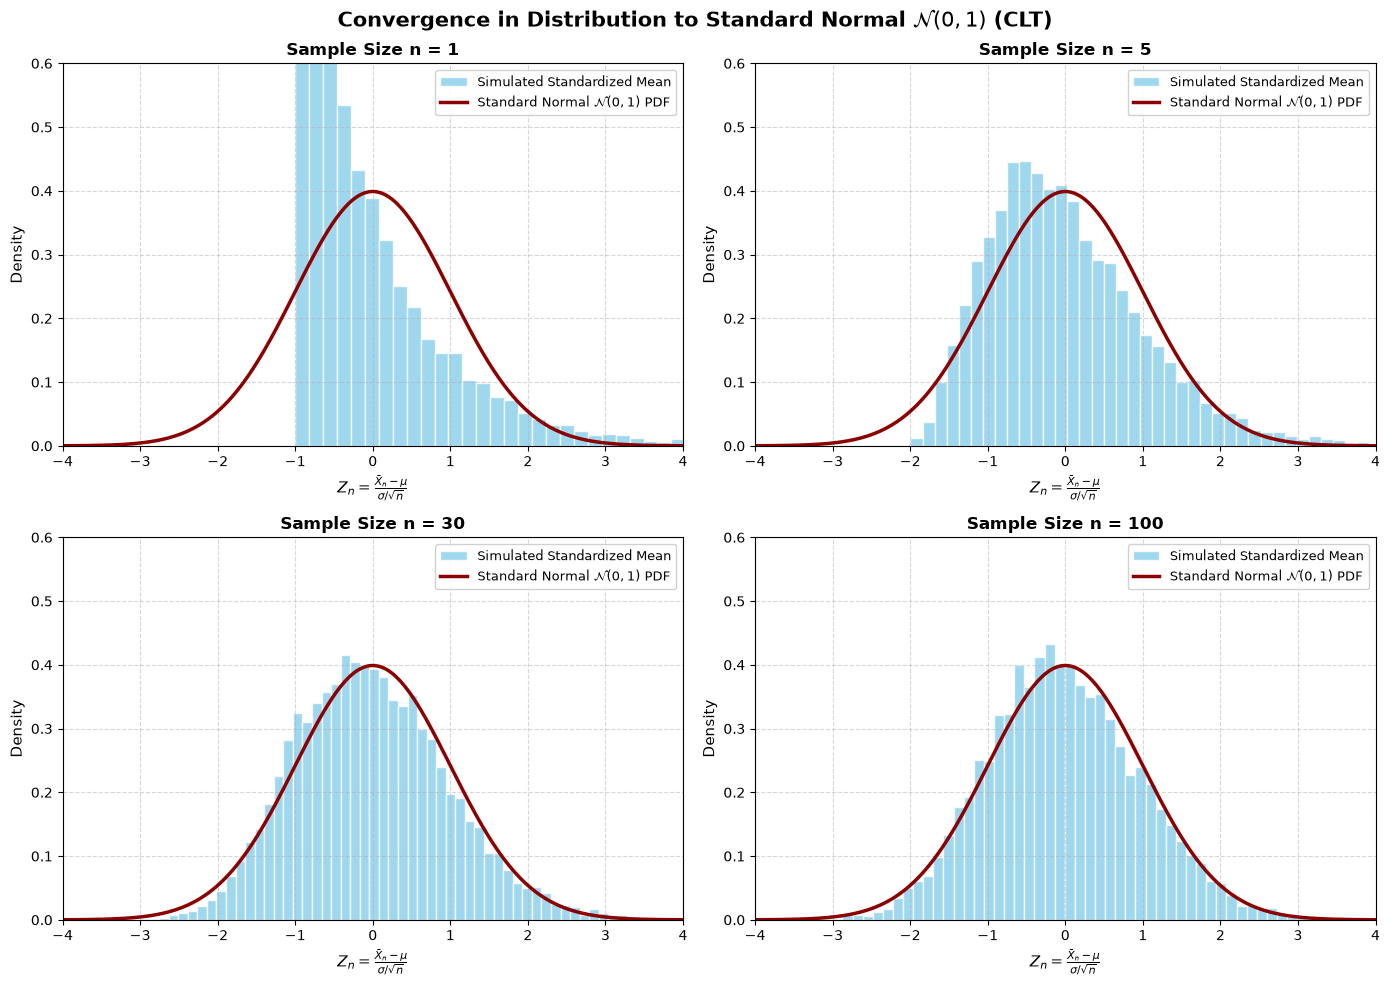

In [2]:
import scipy.stats as stats

# Set random seed
np.random.seed(101)

# Parent distribution: Highly skewed Exponential distribution with mean 1, SD 1
sample_sizes = [1, 5, 30, 100]
num_simulations = 10000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Standard normal reference grid for overlay
z_grid = np.linspace(-4, 4, 300)
normal_pdf = stats.norm.pdf(z_grid, 0, 1)

for idx, n in enumerate(sample_sizes):
    # Simulate num_simulations averages of size n from Exponential(1)
    raw_samples = np.random.exponential(scale=1.0, size=(num_simulations, n))
    sample_means = np.mean(raw_samples, axis=1)
    
    # Standardize sample means: Z_n = (X_bar - mu) / (sigma / sqrt(n))
    standardized_means = (sample_means - 1.0) / (1.0 / np.sqrt(n))
    
    # Plot histogram of standardized means
    axes[idx].hist(standardized_means, bins=60, density=True, color='skyblue', edgecolor='white', alpha=0.8, label=r'Simulated Standardized Mean')
    axes[idx].plot(z_grid, normal_pdf, color='darkred', lw=2.5, label=r'Standard Normal $\mathcal{N}(0,1)$ PDF')
    
    axes[idx].set_title(f"Sample Size n = {n}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(r"$Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}}$", fontsize=11)
    axes[idx].set_ylabel("Density", fontsize=11)
    axes[idx].set_xlim(-4, 4)
    axes[idx].set_ylim(0, 0.6)
    axes[idx].legend(loc='upper right', framealpha=0.9, fontsize=9.5)
    axes[idx].grid(True, linestyle='--', alpha=0.5)

fig.suptitle(r"Convergence in Distribution to Standard Normal $\mathcal{N}(0,1)$ (CLT)", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## 7\. Normal Approximation of the Binomial Distribution

One of the most important practical consequences of the Central Limit Theorem is the **Normal Approximation of the Binomial Distribution** (the De Moivre–Laplace Theorem).

Let $X \sim \text{Bin}(n, p)$ be a [Binomial random variable](bernoulli-and-binomial-distributions.ipynb) representing the total number of successes in $n$ independent Bernoulli trials. We can explicitly write $X$ as the sum of $n$ independent Bernoulli random variables:
$$ X = \sum_{i=1}^n X_i, \quad \text{where } X_i \sim \text{Bern}(p) $$

Because each $X_i$ has mean $E(X_i) = p$ and variance $\text{Var}(X_i) = p(1-p) = pq$ (where $q = 1-p$), the sum $X$ has:
$$
\begin{aligned}
E(X) &= np \\
\text{Var}(X) &= npq
\end{aligned}
$$

::: {#thm-normal-approx-binomial}
## Normal Approximation of the Binomial Distribution (De Moivre–Laplace Theorem)
Let $X \sim \text{Bin}(n, p)$. For large sample sizes $n$, the standardized binomial variable converges in distribution to the standard normal distribution:
$$ \frac{X - np}{\sqrt{npq}} \xrightarrow{d} \mathcal{N}(0, 1) $$
Consequently, the probability that $X$ falls within any interval $[a, b]$ can be approximated using the standard normal cumulative distribution function $\Phi(z)$:
$$ \mathbb{P}(a \le X \le b) = \mathbb{P}\left( \frac{a - np}{\sqrt{npq}} \le \frac{X - np}{\sqrt{npq}} \le \frac{b - np}{\sqrt{npq}} \right) \approx \Phi\left( \frac{b - np}{\sqrt{npq}} \right) - \Phi\left( \frac{a - np}{\sqrt{npq}} \right) $$
:::

### 7.1\. Comparison: Poisson vs. Normal Approximation

When approximating a Binomial distribution $\text{Bin}(n, p)$ for large $n$, two major asymptotic approximations exist depending on the behavior of the success probability $p$:

::: {.callout-note}
## Rule of Thumb: Choosing Between Poisson and Normal Approximations
- **[Poisson Approximation](poisson-distribution.ipynb) (Law of Rare Events):** Use when $n$ is **large**, $p$ is **small** ($p \to 0$), and the expected number of successes $\lambda = np$ is **moderate** (e.g., $p < 0.05$ and $n \ge 20$). The rare occurrences prevent the distribution from becoming symmetric.
- **Normal Approximation (CLT):** Use when $n$ is **large** and $p$ is **around $1/2$** (or not extremely close to $0$ or $1$). In practice, the normal approximation is highly accurate whenever both the expected successes and expected failures satisfy:
  $$ np \ge 5 \quad \text{and} \quad nq = n(1-p) \ge 5 $$
  *(Many texts enforce the slightly stricter condition $np \ge 10$ and $nq \ge 10$ for even higher precision).*
:::


## 8\. Continuity Correction (Yates's Correction)

When applying the continuous Normal approximation to a discrete [Binomial random variable](bernoulli-and-binomial-distributions.ipynb), an inherent boundary discrepancy occurs. A discrete random variable assigns non-zero probability mass to individual integers ($X \in \mathbb{N}$), whereas integrating a continuous probability density over a single point yields zero ($\int_a^a f(x) \, dx = 0$).

To bridge this discrete-to-continuous gap, we apply the **Continuity Correction** (or half-unit correction): we represent every discrete integer value $a$ as a continuous interval of width $1$ centered around $a$, stretching from $a - \frac{1}{2}$ to $a + \frac{1}{2}$.

### 8.1\. Core Continuity Correction Rules

Let $X \sim \text{Bin}(n, p)$ and let $a, b \in \mathbb{Z}$ be integer thresholds. The exact continuity correction formulas are structured as follows:

1. **Probability of an Exact Single Integer Value:**
   To evaluate $\mathbb{P}(X = a)$, we integrate the normal density over the half-unit interval $\left[a - \frac{1}{2}, a + \frac{1}{2}\right]$:
   $$ \mathbb{P}(X = a) = \mathbb{P}\left( a - \frac{1}{2} \le X \le a + \frac{1}{2} \right) \approx \Phi\left( \frac{a + 0.5 - np}{\sqrt{npq}} \right) - \Phi\left( \frac{a - 0.5 - np}{\sqrt{npq}} \right) $$

2. **Inclusive Closed Interval ($\mathbb{P}(a \le X \le b)$):**
   Because the discrete endpoints $a$ and $b$ are included in the event, we expand the continuous integration bounds outwards by half a unit on both sides:
   $$ \mathbb{P}(a \le X \le b) = \mathbb{P}\left( a - \frac{1}{2} \le X \le b + \frac{1}{2} \right) \approx \Phi\left( \frac{b + 0.5 - np}{\sqrt{npq}} \right) - \Phi\left( \frac{a - 0.5 - np}{\sqrt{npq}} \right) $$

3. **Strict Open/Half-Open Intervals (`<` or `>`):**
   When inequalities are strict, first rewrite the event in terms of non-strict integer boundaries ($\le$ or $\ge$) before applying the half-unit adjustment:
   - **Strict Upper Bound:** $\mathbb{P}(a \le X < b) = \mathbb{P}(a \le X \le b - 1) = \mathbb{P}\left( a - \frac{1}{2} \le X \le b - \frac{1}{2} \right)$
   - **Strict Lower Bound:** $\mathbb{P}(a < X \le b) = \mathbb{P}(a + 1 \le X \le b) = \mathbb{P}\left( a + \frac{1}{2} \le X \le b + \frac{1}{2} \right)$
   - **Both Strict Bounds:** $\mathbb{P}(a < X < b) = \mathbb{P}(a + 1 \le X \le b - 1) = \mathbb{P}\left( a + \frac{1}{2} \le X \le b - \frac{1}{2} \right)$
   - **Lower Tail (`at most` vs `less than`):**
     $$
     \begin{aligned}
     \mathbb{P}(X \le b) &= \mathbb{P}\left( X \le b + \frac{1}{2} \right) \approx \Phi\left( \frac{b + 0.5 - np}{\sqrt{npq}} \right) \\
     \mathbb{P}(X < b) &= \mathbb{P}(X \le b - 1) = \mathbb{P}\left( X \le b - \frac{1}{2} \right) \approx \Phi\left( \frac{b - 0.5 - np}{\sqrt{npq}} \right)
     \end{aligned}
     $$
   - **Upper Tail (`at least` vs `greater than`):**
     $$
     \begin{aligned}
     \mathbb{P}(X \ge a) &= \mathbb{P}\left( X \ge a - \frac{1}{2} \right) \approx 1 - \Phi\left( \frac{a - 0.5 - np}{\sqrt{npq}} \right) \\
     \mathbb{P}(X > a) &= \mathbb{P}(X \ge a + 1) = \mathbb{P}\left( X \ge a + \frac{1}{2} \right) \approx 1 - \Phi\left( \frac{a + 0.5 - np}{\sqrt{npq}} \right)
     \end{aligned}
     $$

::: {.callout-warning}
## Common Pitfall: Forgetting to Convert Strict Inequalities
A frequent error is applying $\pm 0.5$ directly to strict inequalities without first converting to inclusive integer bounds. For example, if asked for $\mathbb{P}(X > 10)$, the correct conversion is:
$$ \mathbb{P}(X > 10) \equiv \mathbb{P}(X \ge 11) \implies \text{Continuity Corrected Bound: } 11 - 0.5 = 10.5 $$
If one incorrectly subtracted $0.5$ from $10$, they would compute the probability starting from $9.5$, erroneously including the outcome $X = 10$.
:::


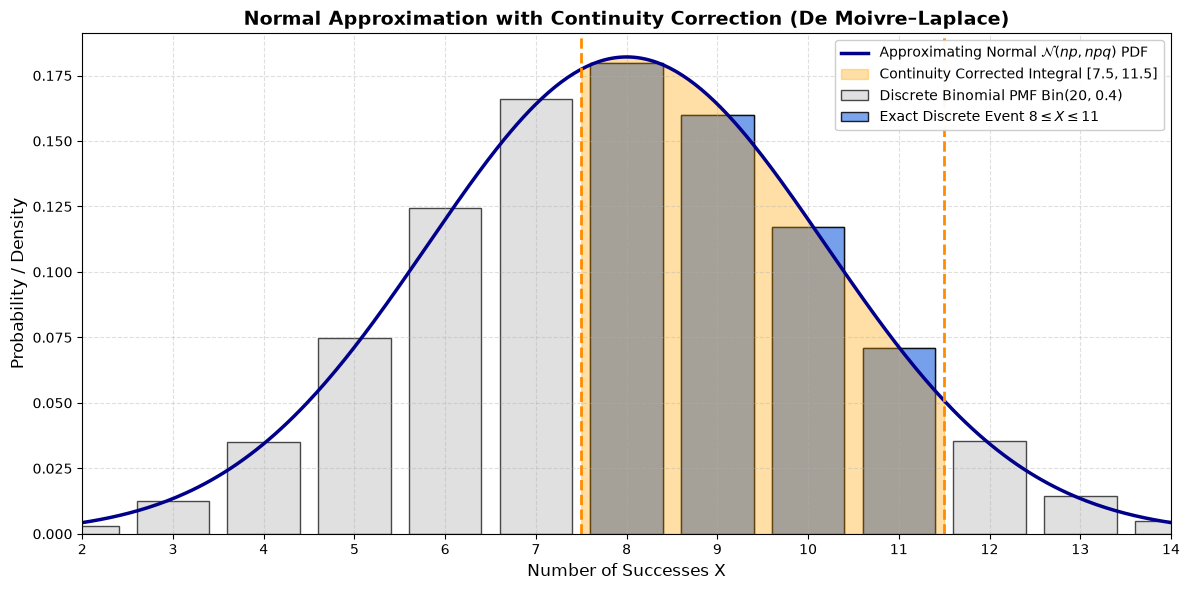

In [3]:
# Parameters for Binomial distribution
n_bin = 20
p_bin = 0.4
mu_bin = n_bin * p_bin          # mean = 8.0
sigma_bin = np.sqrt(n_bin * p_bin * (1 - p_bin)) # sd ~ 2.19089

# Discrete integer values K
k_values = np.arange(0, n_bin + 1)
pmf_values = stats.binom.pmf(k_values, n_bin, p_bin)

# Continuous normal PDF across fine grid
x_grid = np.linspace(1, 15, 400)
pdf_values = stats.norm.pdf(x_grid, mu_bin, sigma_bin)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot discrete PMF bars
ax.bar(k_values, pmf_values, width=0.8, color='lightgray', edgecolor='black', alpha=0.7, label='Discrete Binomial PMF Bin(20, 0.4)')

# Overlay continuous normal PDF
ax.plot(x_grid, pdf_values, color='darkblue', lw=2.5, label=r'Approximating Normal $\mathcal{N}(np, npq)$ PDF')

# Highlight specific interval: P(8 <= X <= 11)
target_k = [8, 9, 10, 11]
ax.bar(target_k, stats.binom.pmf(target_k, n_bin, p_bin), width=0.8, color='cornflowerblue', edgecolor='black', alpha=0.85, label=r'Exact Discrete Event $8 \leq X \leq 11$')

# Highlight continuity corrected interval [7.5, 11.5]
x_fill = np.linspace(7.5, 11.5, 200)
y_fill = stats.norm.pdf(x_fill, mu_bin, sigma_bin)
ax.fill_between(x_fill, y_fill, color='orange', alpha=0.35, label=r'Continuity Corrected Integral $[7.5, 11.5]$')

# Vertical lines showing half-unit expansion boundaries
ax.axvline(7.5, color='darkorange', linestyle='--', lw=2)
ax.axvline(11.5, color='darkorange', linestyle='--', lw=2)

ax.set_title("Normal Approximation with Continuity Correction (De Moivre–Laplace)", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Successes X", fontsize=12)
ax.set_ylabel("Probability / Density", fontsize=12)
ax.set_xlim(2, 14)
ax.set_xticks(range(2, 15))
ax.legend(loc='upper right', framealpha=0.95, fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## 9\. Comprehensive Examples and Worked Applications

We conclude with detailed worked examples demonstrating the application of these convergence theorems and approximation techniques.

### 9.1\. Example 1: Sample Mean Bounds via Weak Law and Chebyshev

**Problem Statement:** Let $X_1, X_2, \dots, X_n$ be a random sample of size $n = 100$ drawn from a population with mean $\mu = 50$ and standard deviation $\sigma = 8$. Use [Chebyshev's Inequality](chebyshevs-inequality.ipynb) to find a lower bound on the probability that the sample mean $\bar{X}_{100}$ falls within the interval $[48, 52]$.

::: {.callout-tip collapse="true"}
## Solution
We are given:
- Sample size $n = 100$
- Population mean $\mu = 50$
- Population standard deviation $\sigma = 8 \implies \text{Var}(X_i) = \sigma^2 = 64$

By properties of the sample mean:
$$
\begin{aligned}
E(\bar{X}_{100}) &= \mu = 50 \\
\text{Var}(\bar{X}_{100}) &= \frac{\sigma^2}{n} = \frac{64}{100} = 0.64
\end{aligned}
$$

We want to lower bound the probability that $\bar{X}_{100} \in [48, 52]$, which corresponds to the deviation threshold $c = 2$:
$$ \mathbb{P}(48 \le \bar{X}_{100} \le 52) = \mathbb{P}\left( |\bar{X}_{100} - 50| \le 2 \right) = 1 - \mathbb{P}\left( |\bar{X}_{100} - 50| > 2 \right) $$

Applying [Chebyshev's Inequality](chebyshevs-inequality.ipynb) to the tail probability:
$$ \mathbb{P}\left( |\bar{X}_{100} - 50| \ge 2 \right) \le \frac{\text{Var}(\bar{X}_{100})}{2^2} = \frac{0.64}{4} = 0.16 $$

Therefore, subtracting from $1$:
$$ \mathbb{P}\left( |\bar{X}_{100} - 50| \le 2 \right) \ge 1 - 0.16 = 0.84 $$
There is at least an $84\%$ probability that the sample mean of $100$ observations lies between $48$ and $52$. $\blacksquare$
:::

### 9.2\. Example 2: Normal Approximation with Continuity Correction

**Problem Statement:** A fair coin is tossed $n = 100$ times. Let $X$ denote the total number of heads obtained. 

**Part (a):** Use the exact Binomial distribution formula to express $\mathbb{P}(45 \le X \le 55)$.

**Part (b):** Approximate $\mathbb{P}(45 \le X \le 55)$ using the Central Limit Theorem **without** continuity correction.

**Part (c):** Approximate $\mathbb{P}(45 \le X \le 55)$ using the Central Limit Theorem **with** continuity correction, and compare the accuracy.

::: {.callout-tip collapse="true"}
## Solution
We have $X \sim \text{Bin}(n=100, p=0.5)$. First, we compute the exact mean and variance of $X$:
$$
\begin{aligned}
E(X) &= np = 100(0.5) = 50 \\
\text{Var}(X) &= npq = 100(0.5)(0.5) = 25 \implies \text{SD}(X) = \sqrt{25} = 5
\end{aligned}
$$
Since $np = 50 \ge 5$ and $nq = 50 \ge 5$, the normal approximation is exceptionally well-justified.

**Part (a): Exact Binomial Expression**
The exact discrete probability is the sum of binomial probabilities:
$$ \mathbb{P}(45 \le X \le 55) = \sum_{k=45}^{55} \binom{100}{k} (0.5)^k (0.5)^{100-k} = (0.5)^{100} \sum_{k=45}^{55} \binom{100}{k} $$
*(Evaluating this sum precisely yields $\mathbb{P}_{\text{exact}} \approx 0.728747$).*

**Part (b): Normal Approximation Without Continuity Correction**
Without continuity correction, we directly standardize the raw boundaries $45$ and $55$:
$$
\begin{aligned}
\mathbb{P}(45 \le X \le 55) &\approx \mathbb{P}\left( \frac{45 - 50}{5} \le Z \le \frac{55 - 50}{5} \right) \\
&= \mathbb{P}(-1.0 \le Z \le 1.0) \\
&= \Phi(1.0) - \Phi(-1.0) \\
&= 2\Phi(1.0) - 1
\end{aligned}
$$
Using standard normal tables ($\Phi(1.0) \approx 0.84134$):
$$ \mathbb{P}_{\text{uncorrected}} \approx 2(0.84134) - 1 = 0.68268 $$
*(Notice that this uncorrected estimate underestimates the true probability by over $4.6\%$ because it ignores the probability mass contained in the outer halves of the bars at $k=45$ and $k=55$).*

**Part (c): Normal Approximation With Continuity Correction**
Because the boundaries $45$ and $55$ are inclusive integer outcomes, we expand the interval by $0.5$ on both sides to $\left[44.5, 55.5\right]$ before standardizing:
$$
\begin{aligned}
\mathbb{P}(45 \le X \le 55) &= \mathbb{P}(44.5 \le X \le 55.5) \\
&\approx \mathbb{P}\left( \frac{44.5 - 50}{5} \le Z \le \frac{55.5 - 50}{5} \right) \\
&= \mathbb{P}\left( \frac{-5.5}{5} \le Z \le \frac{5.5}{5} \right) \\
&= \mathbb{P}(-1.10 \le Z \le 1.10) \\
&= 2\Phi(1.10) - 1
\end{aligned}
$$
Using standard normal tables ($\Phi(1.10) \approx 0.86433$):
$$ \mathbb{P}_{\text{corrected}} \approx 2(0.86433) - 1 = 0.72866 $$

Comparing our results:
- **Exact Binomial Probability:** $0.72875$
- **Corrected Normal Approximation:** $0.72866$ (Error $< 0.0001$, or $0.01\%$)
- **Uncorrected Normal Approximation:** $0.68268$ (Error $\approx 0.046$, or $4.6\%$)

The half-unit continuity correction reduces the approximation error by nearly three orders of magnitude! $\blacksquare$
:::

### 9.3\. Example 3: Required Sample Size for Given Accuracy (CLT Application)

**Problem Statement:** Suppose the service time for customers at a bank server has an unknown distribution with mean $\mu$ minutes and standard deviation $\sigma = 2.5$ minutes. Using the Central Limit Theorem, determine the minimum sample size $n$ required so that the probability that the sample mean service time $\bar{X}_n$ differs from the true mean $\mu$ by at most $0.5$ minutes is at least $95\%$.

::: {.callout-tip collapse="true"}
## Solution
We require the sample size $n$ such that:
$$ \mathbb{P}\left( |\bar{X}_n - \mu| \le 0.5 \right) \ge 0.95 $$

Dividing inside the inequality by the standard deviation of the sample mean $\frac{\sigma}{\sqrt{n}} = \frac{2.5}{\sqrt{n}}$:
$$ \mathbb{P}\left( \frac{-0.5}{2.5 / \sqrt{n}} \le \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \le \frac{0.5}{2.5 / \sqrt{n}} \right) \ge 0.95 $$

By the Central Limit Theorem, $Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}}$ is approximately standard normal $Z \sim \mathcal{N}(0, 1)$. Thus:
$$ \mathbb{P}\left( -0.2\sqrt{n} \le Z \le 0.2\sqrt{n} \right) \ge 0.95 $$

For a standard normal distribution, the central $95\%$ probability interval is bounded by $z_{0.025} \approx 1.96$:
$$ \mathbb{P}(-1.96 \le Z \le 1.96) = 0.95 $$

Therefore, we must set our standardized upper bound equal to at least $1.96$:
$$
\begin{aligned}
0.2\sqrt{n} &\ge 1.96 \\
\sqrt{n} &\ge \frac{1.96}{0.2} = 9.8 \\
n &\ge (9.8)^2 = 96.04
\end{aligned}
$$

Since the sample size $n$ must be an integer, rounding up to the next whole number yields:
$$ n \ge 97 $$
A minimum sample size of $97$ customer observations is needed to achieve the desired accuracy with $95\%$ confidence. $\blacksquare$
:::

> **References & Acknowledgments:**
> Problems and theoretical formulations adapted from *An Introduction to Probability Theory and Its Applications* by William Feller, *A First Course in Probability* by Sheldon Ross, and class lecture notes on convergence of random variables and asymptotic limit theorems.
